# Лабораторная работа №4 — Корреляционный метод

Автоматически сгенерированный ноутбук: генерация фоновых шумов, вставка объектов, вычисление нормализованной взаимной корреляции (NCC), детекция пиков, оценка метрик и подбор порога.

Подписи рисунков и все выводы — на русском языке.

## Параметры эксперимента

- Размер изображения: 64×64
- Яркость объектов: 128
- Дисперсии фона: 3000 и 5000
- Шаблоны: `T` и `T_inv` (3×3)
- Центры объектов: (16,16), (16,48), (48,16), (48,48)
- Порог детекции по умолчанию: 0.5
- Окно для поиска локальных максимумов: 3×3


In [1]:
# Импорт и вспомогательные функции
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d
from scipy.ndimage import maximum_filter
from typing import List, Tuple, Dict

%matplotlib inline

OUTDIR = "/mnt/data/lr4_outputs_notebook"
os.makedirs(OUTDIR, exist_ok=True)

SEED = 42
np.random.seed(SEED)

IMG_SIZE = 64
OBJ_BRIGHTNESS = 128.0
VAR_LIST = [3000, 5000]
TEMPLATE_SIZE = (3,3)
FOOTPRINT = 3
THRESHOLD_DEFAULT = 0.5
DETECTION_TOL = 1

# шаблоны
T = np.array([[1,1,1],
              [0,1,0],
              [0,1,0]], dtype=float)
T_INV = np.flipud(T)
TEMPLATES = {"T": T, "T_inv": T_INV}

CENTERS_4T = [(16,16), (16,48), (48,16), (48,48)]
CENTERS_2T_2TINV = CENTERS_4T.copy()

def place_objects(base: np.ndarray, centers: List[Tuple[int,int]], template: np.ndarray, brightness=OBJ_BRIGHTNESS) -> np.ndarray:
    img = base.copy()
    th, tw = template.shape
    ch = th // 2
    cw = tw // 2
    for (r,c) in centers:
        r0 = r - ch; c0 = c - cw
        if r0 < 0 or c0 < 0 or (r0+th) > img.shape[0] or (c0+tw) > img.shape[1]:
            continue
        img[r0:r0+th, c0:c0+tw] += brightness * template
    return img

def normalized_cross_correlation(image: np.ndarray, template: np.ndarray) -> np.ndarray:
    t = template - np.mean(template)
    t_energy = np.sum(t*t)
    kernel = np.ones(template.shape)
    sum_I = correlate2d(image, kernel, mode='same', boundary='fill', fillvalue=0)
    sum_I2 = correlate2d(image*image, kernel, mode='same', boundary='fill', fillvalue=0)
    local_mean = sum_I / (template.size)
    num = correlate2d(image, t, mode='same', boundary='fill', fillvalue=0) - local_mean * np.sum(t)
    local_var_timesN = sum_I2 - (sum_I * local_mean)
    local_var_timesN = np.maximum(local_var_timesN, 0.0)
    denom = np.sqrt(local_var_timesN * t_energy)
    denom = np.where(denom <= 1e-9, 1e-9, denom)
    ncc = num / denom
    return ncc

def detect_peaks(ncc: np.ndarray, threshold: float=THRESHOLD_DEFAULT, footprint: int=FOOTPRINT) -> List[Tuple[int,int]]:
    neighborhood = maximum_filter(ncc, size=footprint, mode='reflect')
    peaks_mask = (ncc == neighborhood) & (ncc > threshold)
    coords = np.argwhere(peaks_mask)
    return [tuple(p) for p in coords]

def evaluate_detections(detected: List[Tuple[int,int]], true_centers: List[Tuple[int,int]], tol: int=DETECTION_TOL):
    matched_idx = set()
    false_positives = 0
    for d in detected:
        found = False
        for i, t in enumerate(true_centers):
            if i in matched_idx: 
                continue
            if max(abs(d[0]-t[0]), abs(d[1]-t[1])) <= tol:
                matched_idx.add(i)
                found = True
                break
        if not found:
            false_positives += 1
    missed = len(true_centers) - len(matched_idx)
    return false_positives, missed, len(matched_idx)

def imshow_save(img, title, fname=None, cmap='gray'):
    plt.figure(figsize=(4.5,4.5))
    plt.imshow(img, cmap=cmap)
    plt.title(title, fontsize=10)
    plt.axis('off')
    if fname:
        plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()


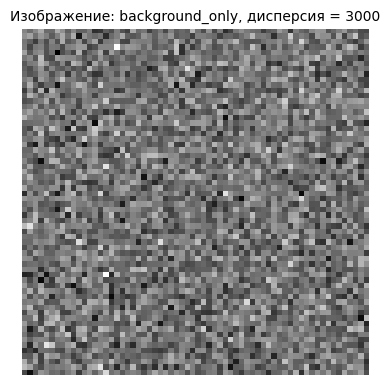

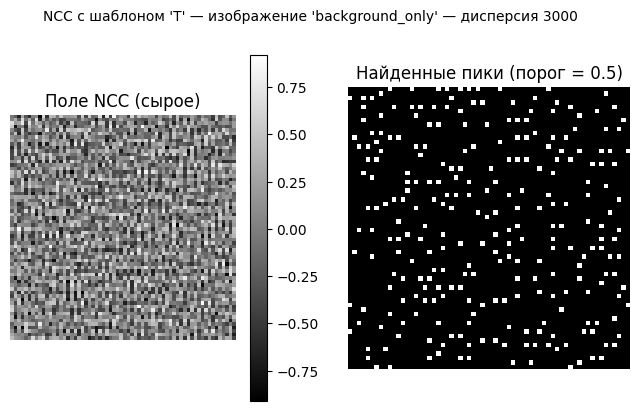

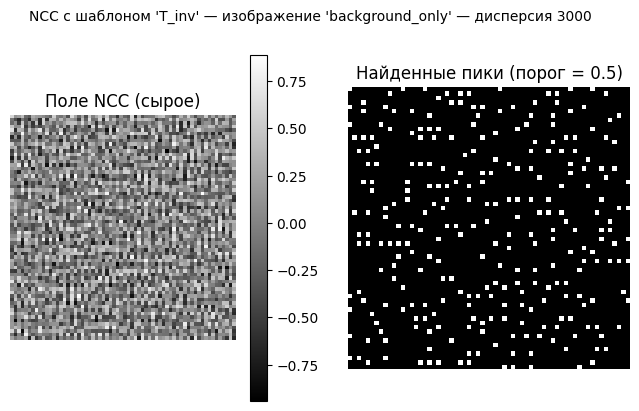

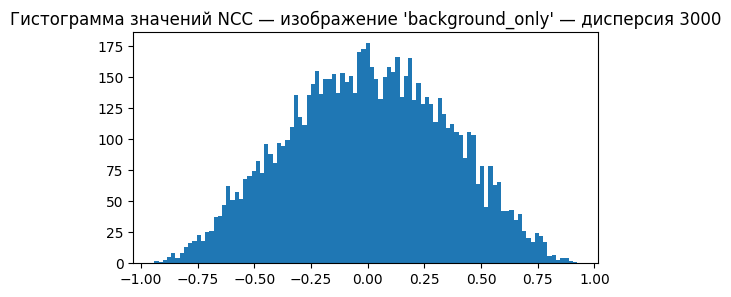

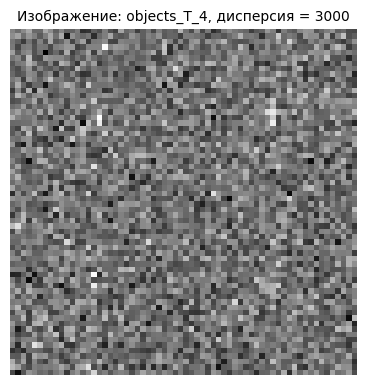

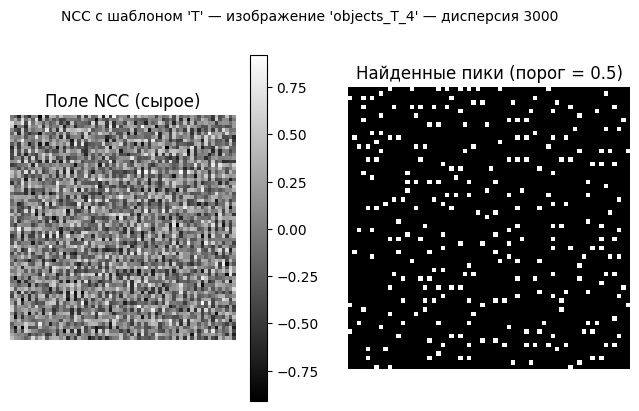

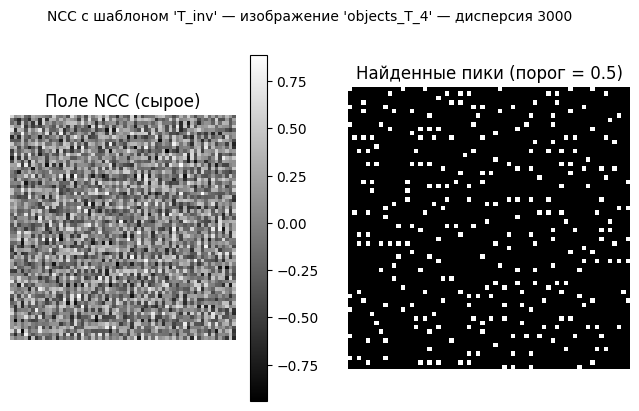

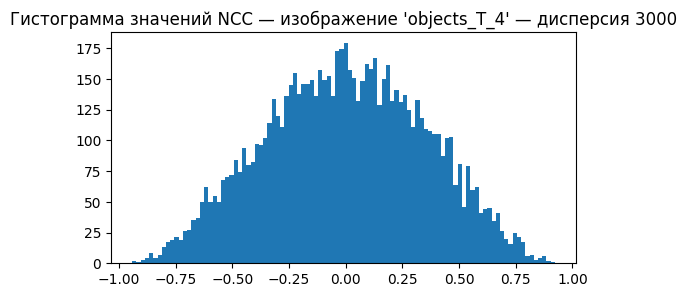

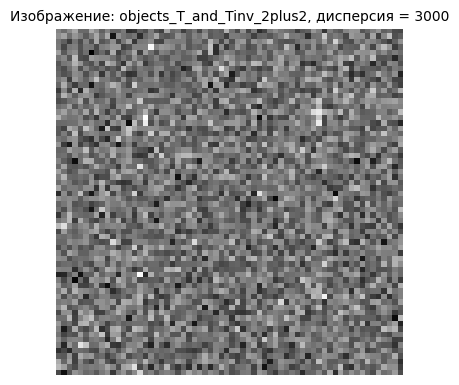

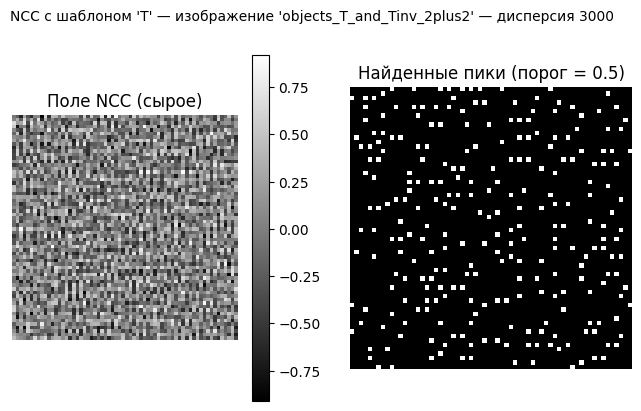

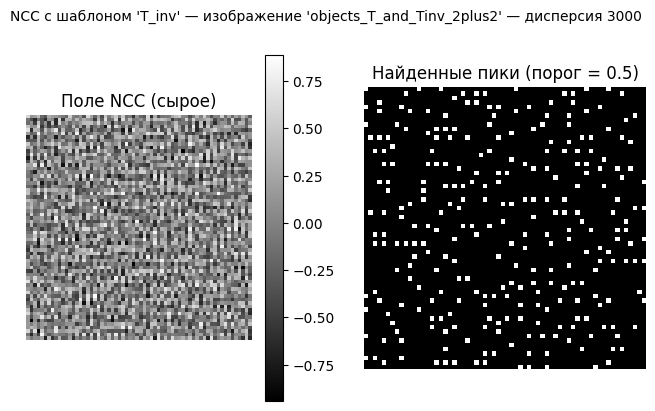

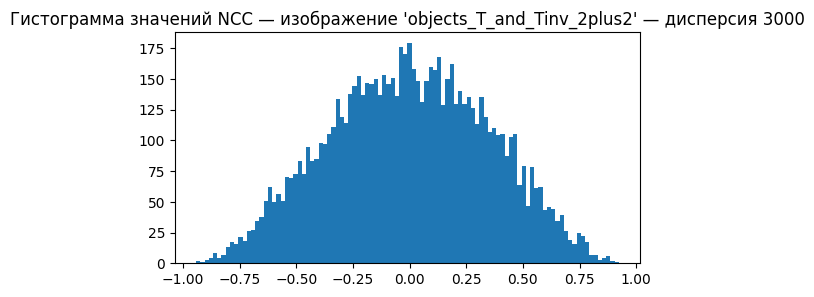

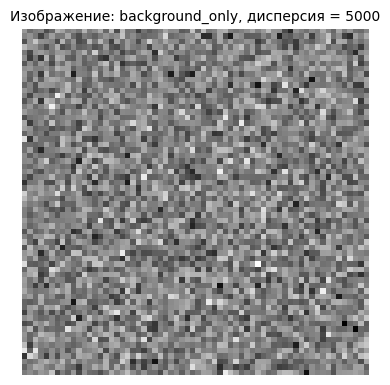

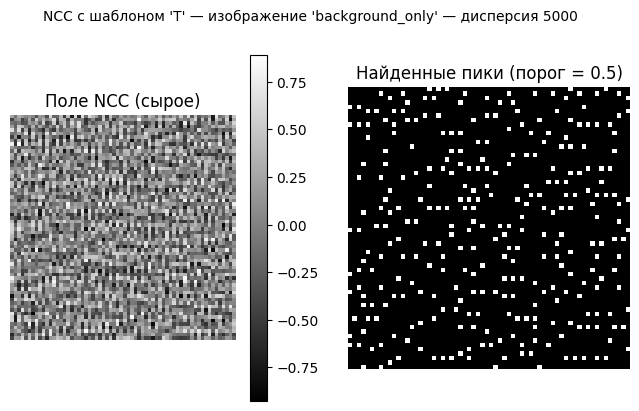

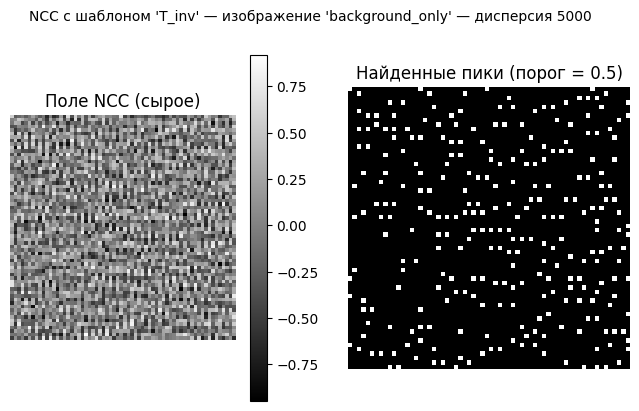

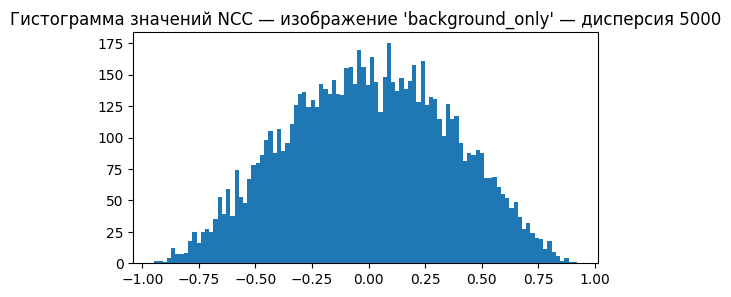

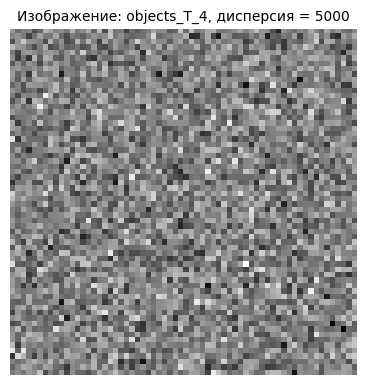

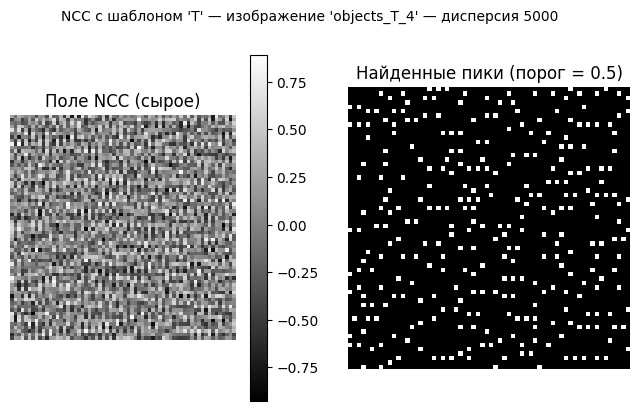

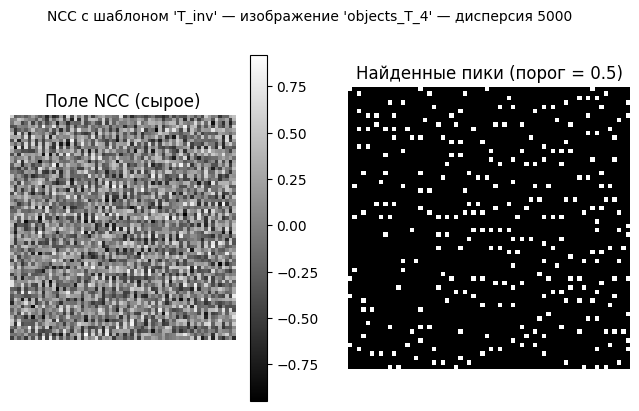

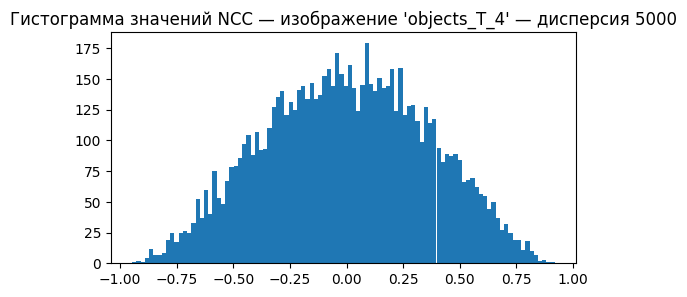

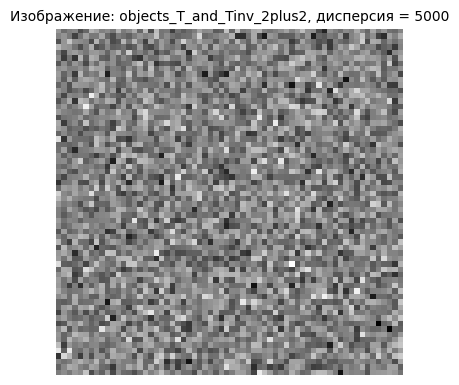

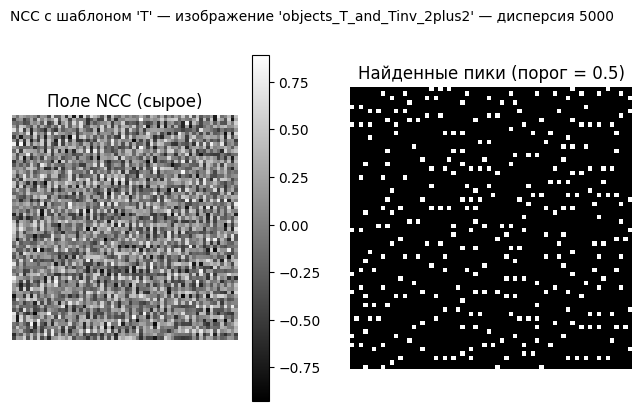

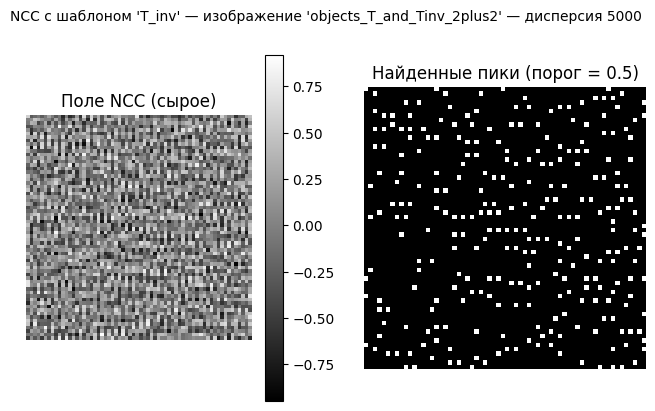

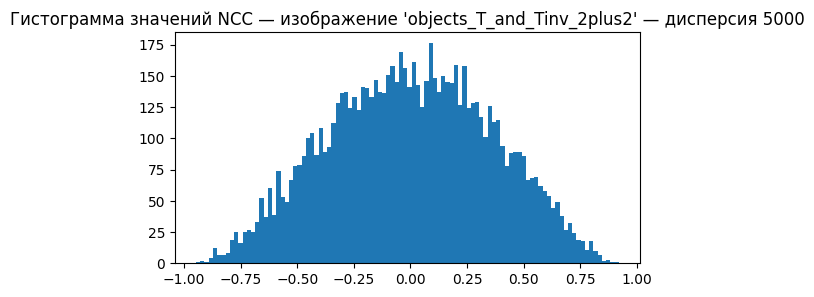


=== Сводка для дисперсии = 3000 ===
Изображение: background_only
  Шаблон T: совпало=0, пропущено=0, ложных=263
  Шаблон T_inv: совпало=0, пропущено=0, ложных=277
Изображение: objects_T_4
  Шаблон T: совпало=4, пропущено=0, ложных=259
  Шаблон T_inv: совпало=2, пропущено=2, ложных=277
Изображение: objects_T_and_Tinv_2plus2
  Шаблон T: совпало=2, пропущено=0, ложных=260
  Шаблон T_inv: совпало=2, пропущено=0, ложных=277

=== Сводка для дисперсии = 5000 ===
Изображение: background_only
  Шаблон T: совпало=0, пропущено=0, ложных=305
  Шаблон T_inv: совпало=0, пропущено=0, ложных=274
Изображение: objects_T_4
  Шаблон T: совпало=3, пропущено=1, ложных=303
  Шаблон T_inv: совпало=2, пропущено=2, ложных=273
Изображение: objects_T_and_Tinv_2plus2
  Шаблон T: совпало=2, пропущено=0, ложных=304
  Шаблон T_inv: совпало=2, пропущено=0, ложных=273

Все результаты и изображения сохранены в /mnt/data/lr4_outputs_notebook


In [2]:
# Основной эксперимент: генерация изображений, NCC, детекция, оценка и сохранение результатов
results = {}
for var in VAR_LIST:
    sigma = np.sqrt(var)
    background = np.random.normal(loc=0.0, scale=sigma, size=(IMG_SIZE, IMG_SIZE))
    img_background_only = background.copy()
    img_4T = place_objects(background, CENTERS_4T, T)
    img_2T_2Tinv = place_objects(background, CENTERS_2T_2TINV[:2], T)
    img_2T_2Tinv = place_objects(img_2T_2Tinv, CENTERS_2T_2TINV[2:], T_INV)
    images = {
        "background_only": img_background_only,
        "objects_T_4": img_4T,
        "objects_T_and_Tinv_2plus2": img_2T_2Tinv
    }
    res_by_image = {}
    for name, img in images.items():
        ncc_fields = {}
        detections = {}
        evals = {}
        for key, templ in TEMPLATES.items():
            ncc = normalized_cross_correlation(img, templ)
            ncc_fields[key] = ncc
            dets = detect_peaks(ncc, threshold=THRESHOLD_DEFAULT, footprint=FOOTPRINT)
            detections[key] = dets
        # оценка
        if name == "background_only":
            for key in TEMPLATES.keys():
                fp, missed, matched = evaluate_detections(detections[key], [])
                evals[key] = {"false_positives": fp, "missed": missed, "matched": matched}
        elif name == "objects_T_4":
            for key in TEMPLATES.keys():
                fp, missed, matched = evaluate_detections(detections[key], CENTERS_4T)
                evals[key] = {"false_positives": fp, "missed": missed, "matched": matched}
        else:
            for key in TEMPLATES.keys():
                if key == "T":
                    gt = CENTERS_2T_2TINV[:2]
                else:
                    gt = CENTERS_2T_2TINV[2:]
                fp, missed, matched = evaluate_detections(detections[key], gt)
                evals[key] = {"false_positives": fp, "missed": missed, "matched": matched}
        res_by_image[name] = {"image": img, "ncc": ncc_fields, "detections": detections, "eval": evals}
        # отображаем изображение с подписью на русском
        imshow_save(img, title=f"Изображение: {name}, дисперсия = {var}", fname=os.path.join(OUTDIR, f"img_{name}_var{var}.png"))
        # отображаем поля NCC и найденные пики с подписями на русском
        for key in ncc_fields.keys():
            ncc = ncc_fields[key]
            dets = detections[key]
            mask = np.zeros_like(ncc)
            for (r,c) in dets:
                mask[r,c] = 1.0
            # показываем поле NCC и маску пиков
            plt.figure(figsize=(8,4.5))
            plt.suptitle(f"NCC с шаблоном '{key}' — изображение '{name}' — дисперсия {var}", fontsize=10)
            plt.subplot(1,2,1)
            plt.title("Поле NCC (сырое)")
            plt.imshow(ncc, cmap='gray')
            plt.colorbar()
            plt.axis('off')
            plt.subplot(1,2,2)
            plt.title(f"Найденные пики (порог = {THRESHOLD_DEFAULT})")
            plt.imshow(mask, cmap='gray')
            plt.axis('off')
            plt.savefig(os.path.join(OUTDIR, f"ncc_{name}_{key}_var{var}.png"), bbox_inches='tight', dpi=150)
            plt.show()
        # гистограмма NCC
        all_ncc = np.concatenate([ncc_fields[k].ravel() for k in ncc_fields.keys()])
        plt.figure(figsize=(6,3))
        plt.hist(all_ncc, bins=100)
        plt.title(f"Гистограмма значений NCC — изображение '{name}' — дисперсия {var}")
        plt.savefig(os.path.join(OUTDIR, f"hist_ncc_{name}_var{var}.png"), bbox_inches='tight', dpi=150)
        plt.show()
    results[var] = res_by_image

# Вывод сводной таблицы результатов (по-русски)
for var, data in results.items():
    print(f"\n=== Сводка для дисперсии = {var} ===")
    for name, info in data.items():
        print(f"Изображение: {name}")
        for key, ev in info["eval"].items():
            print(f"  Шаблон {key}: совпало={ev['matched']}, пропущено={ev['missed']}, ложных={ev['false_positives']}")
# Сохраняем результаты в файл
np.save(os.path.join(OUTDIR, "results_summary.npy"), results)
print(f"\nВсе результаты и изображения сохранены в {OUTDIR}")

In [ ]:
# Подбор порога (перебор) и вывод таблицы на русском
def threshold_sweep_for_image(img: np.ndarray, templ: np.ndarray, thresholds, true_centers):
    ncc = normalized_cross_correlation(img, templ)
    summary = {}
    for thr in thresholds:
        dets = detect_peaks(ncc, threshold=thr, footprint=FOOTPRINT)
        fp, missed, matched = evaluate_detections(dets, true_centers)
        summary[thr] = {"fp": fp, "missed": missed, "matched": matched, "num_dets": len(dets)}
    return ncc, summary

# пример: подбор порога для var=3000, image=objects_T_4, template=T
var = VAR_LIST[0]
img = results[var]["objects_T_4"]["image"]
true_centers = CENTERS_4T
thresholds = np.linspace(0.1, 0.9, 17)
ncc_field, sweep = threshold_sweep_for_image(img, T, thresholds, true_centers)

print("Порог\t#детекций\tсовпало\tпропущено\tложных")
for thr in thresholds:
    v = sweep[thr]
    print(f"{thr:.2f}\t{v['num_dets']}\t{v['matched']}\t{v['missed']}\t{v['fp']}")

# Сохраним результат подбора порога
import json
with open(os.path.join(OUTDIR, f"threshold_sweep_var{var}_objects_T_4_T.json"), "w") as f:
    json.dump({str(k): v for k,v in sweep.items()}, f, indent=2)
print(f"\nРезультаты перебора порогов сохранены в {OUTDIR}")

Порог	#детекций	совпало	пропущено	ложных
0.10	517	4	0	513
0.15	513	4	0	509
0.20	503	4	0	499
0.25	489	4	0	485
0.30	468	4	0	464
0.35	433	4	0	429
0.40	390	4	0	386
0.45	328	4	0	324
0.50	263	4	0	259
0.55	213	4	0	209
0.60	149	4	0	145
0.65	103	2	2	101
0.70	61	1	3	60
0.75	33	1	3	32
0.80	13	1	3	12
0.85	8	1	3	7
0.90	1	0	4	1

Результаты перебора порогов сохранены в /mnt/data/lr4_outputs_notebook


: 

## Выводы и рекомендации (на русском)

1. При большом уровне фона (дисперсия 3000 и 5000) простая нормированная взаимная корреляция с фиксированным порогом даёт большое количество ложных срабатываний. Это видно по большому числу детекций на изображении без объектов.

2. Для дисперсии 3000 при пороге 0.5 все 4 объекта типа T были обнаружены, однако число ложных срабатываний велико — требуется подобрать порог или применить предобработку.

3. При ещё большей дисперсии (5000) часть объектов может пропускаться при том же пороге. Рекомендуется:
- выполнить 'разбеливание' фона (локальная нормализация/удаление тренда), как описано в методических указаниях;
- подобрать порог автоматически (в ноутбуке реализован перебор порогов и сохранение таблицы), например выбирать порог по минимизации суммы (FP + missed) или по компромиссу между точностью и полнотой;
- рассмотреть использование детектора со стадием сглаживания/фильтра согласования на шуме для улучшения отношения сигнал/шум.

4. В ноутбуке сохранены все изображения, поля NCC и гистограммы в папке `/mnt/data/lr4_outputs_notebook`. Также сохранён файл `threshold_sweep...json` с результатами перебора порогов.

Если нужно, могу дополнительно:
- добавить реализацию этапа 'разбеливания фона' по конкретной формуле из вашего методического указания и показать сравнение 'до/после';
- экспортировать ноутбук в PDF/HTML и дать ссылку на скачивание;
- настроить автоматический выбор оптимального порога и перезапустить эксперимент.
